# Transition Temperatures

`plot_phase_diagram(..., transition_temperatures=True)` labels every invariant of a refined phase diagram with its temperature.
Two kinds of point are tagged in the `locus` column of the `calc_phase_diagram` frame:

* `triple`: three phases coexist on an isotherm (eutectic, peritectic, eutectoid, peritectoid),
* `congruent`: two coexisting phases share a composition (congruent melting point, congruent minimum or maximum of a lens, the melting point of a pure component).

This notebook builds the textbook binary systems, one per reaction, from `LinePhase`, `IdealSolution` and `RegularSolution`.

## Prelude

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from landau.phases import LinePhase, IdealSolution, RegularSolution, kB
from landau.calculate import calc_phase_diagram
from landau.plot import plot_phase_diagram, plot_mu_phase_diagram

Energies are in eV/atom, entropies in units of $k_B$.
A line phase has $f(T) = E - T S$, so a pure component melts at $T_m = \Delta E / \Delta S$.

In [2]:
def line(name, c, E, S):
    return LinePhase(name, fixed_concentration=c, line_energy=E, line_entropy=S * kB)

def ideal(name, E_A, S_A, E_B, S_B):
    """Ideal solution between the terminals A (c=0) and B (c=1)."""
    return IdealSolution(name, line(name + "A", 0, E_A, S_A), line(name + "B", 1, E_B, S_B))

def regular(name, E_A, S_A, E_B, S_B, L0):
    """Regular solution with mixing enthalpy L0 c (1 - c); L0 < 0 attracts, L0 > 0 repels."""
    return RegularSolution(
        name,
        phases=[
            line(name + "A", 0, E_A, S_A),
            line(name + "mid", 0.5, (E_A + E_B) / 2 + L0 / 4, (S_A + S_B) / 2),
            line(name + "B", 1, E_B, S_B),
        ],
        num_coeffs=1,
        add_entropy=True,
    )

A = line("A", 0, -3.0, 1.0)
B = line("B", 1, -2.5, 1.0)
liquid = ideal("liquid", -2.8, 3.0, -2.35, 3.0)
Ts = np.linspace(300, 1500, 60)

def diagram(phases, ax=None):
    df = calc_phase_diagram(phases, Ts, mu=100)
    plot_phase_diagram(df, element="B", transition_temperatures=True, ax=ax)
    return df

## Congruent minimum

Ideal solid and liquid solutions form a lens between the two melting points.
An attractive liquid pulls the lens below both, and where solidus and liquidus touch the two phases share a composition: a congruent point.
The pure-component melting points are the same kind of point.

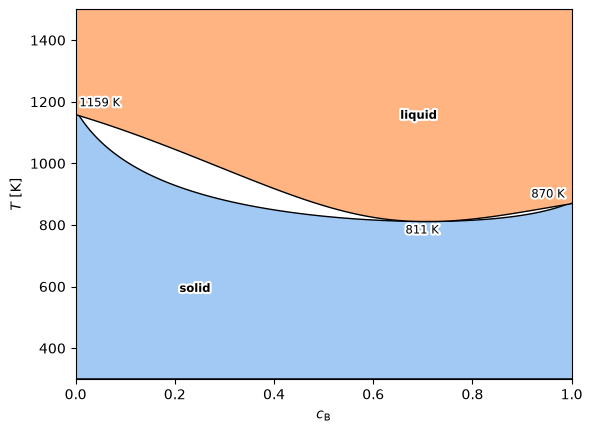

In [3]:
solid = ideal("solid", -3.0, 1.0, -2.5, 1.0)
liquid_attractive = regular("liquid", -2.8, 3.0, -2.35, 3.0, L0=-0.12)
df = diagram([solid, liquid_attractive])

In [4]:
df.query("locus == 'congruent'").sort_values("T")[["T", "c", "phase", "locus"]]

,T,c,phase,locus
12425,811.139529,0.703157,liquid,congruent
12424,811.139529,0.699434,solid,congruent
12427,870.255141,0.999875,solid,congruent
12426,870.255141,0.999683,liquid,congruent
12120,1158.563053,0.000732,solid,congruent
12121,1158.563053,0.003966,liquid,congruent


## Eutectic

$L \rightarrow A + B$.
Two line phases with no mutual solubility and an ideal liquid.
The three-phase isotherm is drawn as a line, its temperature labelled in the two-phase field above it.
In the $\mu$-$T$ diagram the three phases meet in a point.

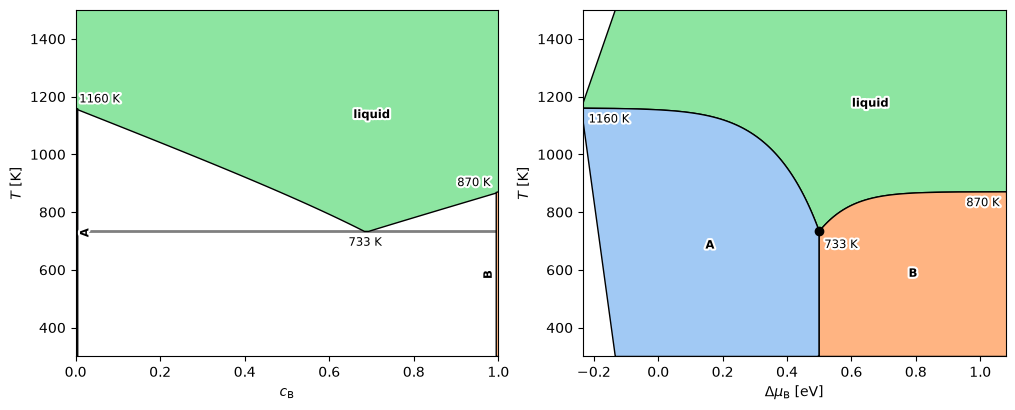

In [5]:
fig, (ax_c, ax_mu) = plt.subplots(1, 2, figsize=(12, 4.5))
df = diagram([A, B, liquid], ax=ax_c)
plot_mu_phase_diagram(df, element="B", transition_temperatures=True, ax=ax_mu)

In [6]:
df.query("locus == 'triple'")[["T", "c", "phase", "locus"]]

,T,c,phase,locus
18120,733.282818,0.000000,A,triple
18121,733.282818,1.000000,B,triple
18122,733.282818,0.688104,liquid,triple


## Peritectic

$L + A \rightarrow AB$.
The compound AB melts incongruently: above the peritectic temperature it decomposes into A and a liquid richer in B than itself.
The B-rich side ends in an ordinary eutectic.
A is given a higher melting point here so the two isotherms sit well apart.

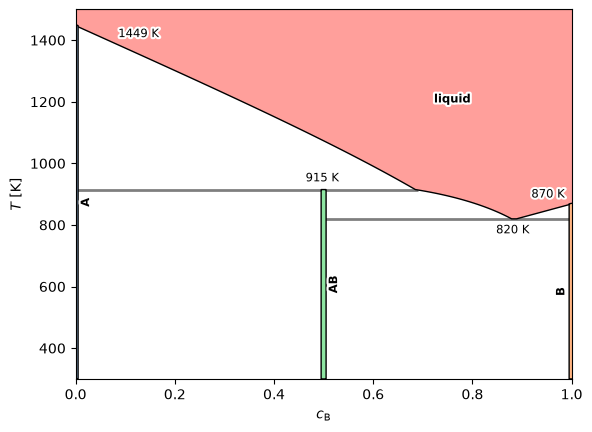

In [7]:
liquid_hot = ideal("liquid", -2.75, 3.0, -2.35, 3.0)
AB = line("AB", 0.5, -2.80, 0.6)
df = diagram([A, B, AB, liquid_hot])

## Congruently melting compound

A more stable AB melts directly into a liquid of its own composition; a congruent maximum in the liquidus, with a eutectic on either side.

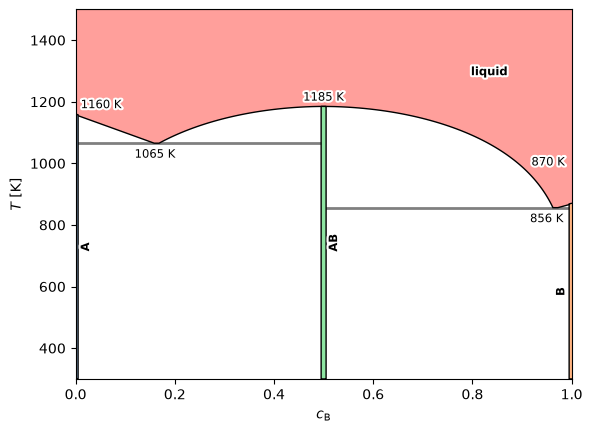

In [8]:
AB = line("AB", 0.5, -2.85, 1.0)
df = diagram([A, B, AB, liquid])

## Eutectoid

$\gamma \rightarrow A + B$.
The eutectic geometry with the liquid replaced by a solid solution $\gamma$; a liquid on top melts $\gamma$ through an isomorphous lens.
The allotropic transitions of the pure components, $A \leftrightarrow \gamma$ and $B \leftrightarrow \gamma$, are congruent points too.

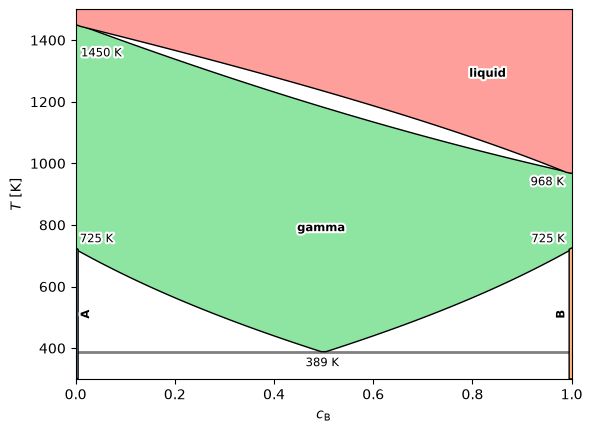

In [9]:
gamma = ideal("gamma", -2.95, 1.8, -2.45, 1.8)
df = diagram([A, B, gamma, liquid])

## Peritectoid

$A + B \rightarrow AB$.
A low-entropy compound that is only stable at low temperature; on heating it decomposes into the two solids, well below the eutectic.

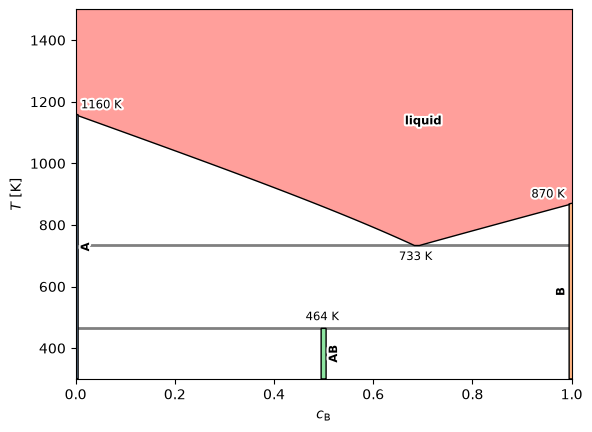

In [10]:
AB = line("AB", 0.5, -2.77, 0.5)
df = diagram([A, B, AB, liquid])

In [11]:
df.query("locus in ['triple', 'congruent']").groupby(["T", "locus"]).phase.agg(list)

T            locus    
464.180753   triple           [B, A, AB]
733.282806   triple       [B, liquid, A]
870.265486   congruent       [B, liquid]
1159.924122  congruent       [A, liquid]
Name: phase, dtype: object

## Notes

* The labels only read the `locus` tags back, so an unrefined diagram (`refine=False`) draws none.
* `transition_temperatures=True` also draws the three-phase isotherms; pass `triplepoints=False` to keep only the labels.
* Invariants in which one phase takes part twice, the monotectic $L_1 \rightarrow A + L_2$ and the syntectic, are not tagged: landau sees a single liquid phase there.